# Calculate 'พรรคเล็ก'

In [1]:
import pandas as pd

PARTY_NAMES = [
    "กรีน",
    "กล้าธรรม",
    "ก้าวอิสระ",
    "ครูไทยเพื่อประชาชน",
    "คลองไทย",
    "ความหวังใหม่",
    "ทางเลือกใหม่",
    "ท้องที่ไทย",
    "ประชากรไทย",
    "ประชาชน",
    "ประชาชาติ",
    "ประชาธิปัตย์",
    "ประชาธิปไตยใหม่",
    "ประชาอาสาชาติ",
    "ประชาไทย",
    "ปวงชนไทย",
    "พร้อม",
    "พลวัต",
    "พลังธรรมใหม่",
    "พลังประชารัฐ",
    "พลังสังคมใหม่",
    "พลังเพื่อไทย",
    "พลังไทยรักชาติ",
    "ฟิวชัน",
    "ภูมิใจไทย",
    "มิติใหม่",
    "รวมพลัง",
    "รวมพลังประชาชน",
    "รวมใจไทย",
    "รวมไทยสร้างชาติ",
    "รักชาติ",
    "รักษ์ธรรม",
    "วิชชั่นใหม่",
    "สร้างอนาคตไทย",
    "สังคมประชาธิปไตยไทย",
    "สัมมาธิปไตย",
    "อนาคตไทย",
    "เครือข่ายชาวนาแห่งประเทศไทย",
    "เป็นธรรม",
    "เพื่อชาติไทย",
    "เพื่อชีวิตใหม่",
    "เพื่อบ้านเมือง",
    "เพื่อไทย",
    "เศรษฐกิจ",
    "เสรีรวมไทย",
    "แผ่นดินธรรม",
    "แรงงานสร้างชาติ",
    "โอกาสใหม่",
    "ใหม่",
    "ไทยก้าวหน้า",
    "ไทยก้าวใหม่",
    "ไทยชนะ",
    "ไทยทรัพย์ทวี",
    "ไทยธรรม",
    "ไทยพร้อม",
    "ไทยพิทักษ์ธรรม",
    "ไทยภักดี",
    "ไทยรวมไทย",
    "ไทยสร้างไทย",
    "ไทรวมพลัง",
]

df = pd.DataFrame({"Party": PARTY_NAMES})
df

,Party
0,กรีน
1,กล้าธรรม
2,ก้าวอิสระ
3,ครูไทยเพื่อประชาชน
4,คลองไทย
5,ความหวังใหม่
6,ทางเลือกใหม่
7,ท้องที่ไทย
8,ประชากรไทย
9,ประชาชน


## Ratio ของจำนวน สส. ที่ส่ง

In [2]:
import pandas as pd 

sent_pm = pd.read_csv('data/scrape/pm_sent.csv')
sent_pm

,Party,สส_เขต,สส_บัญชีรายชื่อ
0,กรีน,2,12
1,กล้าธรรม,334,100
2,ก้าวอิสระ,6,15
3,ครูไทยเพื่อประชาชน,1,22
4,คลองไทย,2,16
5,ความหวังใหม่,1,8
6,ทางเลือกใหม่,43,20
7,ท้องที่ไทย,2,8
8,ประชากรไทย,42,18
9,ประชาชน,400,99


### Ratio of จำนวนสส. ที่ส่ง / จำนวนที่นั่งในสภา

In [3]:
TOTAL_DISTRICT_PM = 400
TOTAL_DISTRICT_PARTYLIST = 100

sent_pm["sent_pm_district_ratio"] = sent_pm["สส_เขต"] / TOTAL_DISTRICT_PM
sent_pm["sent_pm_partylist_ratio"] = sent_pm["สส_บัญชีรายชื่อ"] / TOTAL_DISTRICT_PARTYLIST

df = df.drop(columns=["sent_pm_district_ratio", "sent_pm_partylist_ratio"], errors="ignore")
df = df.join(
    sent_pm.set_index("Party")[["sent_pm_district_ratio", "sent_pm_partylist_ratio"]],
    on="Party",
)
df

,Party,sent_pm_district_ratio,sent_pm_partylist_ratio
0,กรีน,0.0050,0.12
1,กล้าธรรม,0.8350,1.00
2,ก้าวอิสระ,0.0150,0.15
3,ครูไทยเพื่อประชาชน,0.0025,0.22
4,คลองไทย,0.0050,0.16
5,ความหวังใหม่,0.0025,0.08
6,ทางเลือกใหม่,0.1075,0.20
7,ท้องที่ไทย,0.0050,0.08
8,ประชากรไทย,0.1050,0.18
9,ประชาชน,1.0000,0.99


## Follower on Social Media (Facebook)

In [4]:
import numpy as np

followers = pd.read_csv("data/scrape/follower.csv")
followers["name"] = followers["name"].astype(str).str.strip()
followers["followers"] = pd.to_numeric(followers["followers"], errors="coerce").fillna(0)

followers_log = np.log1p(followers["followers"])
min_val = followers_log.min()
max_val = followers_log.max()

if max_val == min_val:
    followers["social_media_followers_scaled"] = 0.0
else:
    followers["social_media_followers_scaled"] = (followers_log - min_val) / (max_val - min_val)

followers

,name,followers,social_media_followers_scaled
0,ใหม่,86000.0,0.816782
1,มิติใหม่,1600.0,0.530406
2,รวมไทยสร้างชาติ,191000.0,0.874142
3,พลวัต,6300.0,0.628896
4,ประชาธิปไตยใหม่,147.0,0.359232
5,เพื่อไทย,1000000.0,0.993148
6,ทางเลือกใหม่,4000.0,0.596248
7,เศรษฐกิจ,488000.0,0.941574
8,เสรีรวมไทย,225000.0,0.885919
9,รวมพลังประชาชน,1800.0,0.538868


In [5]:
df = df.drop(columns=["social_media_followers_scaled"], errors="ignore")
df = df.join(
    followers.set_index("name")[["social_media_followers_scaled"]],
    on="Party",
)
df["social_media_followers_scaled"] = df["social_media_followers_scaled"].fillna(0)
df

,Party,sent_pm_district_ratio,sent_pm_partylist_ratio,social_media_followers_scaled
0,กรีน,0.0050,0.12,0.652096
1,กล้าธรรม,0.8350,1.00,0.836410
2,ก้าวอิสระ,0.0150,0.15,0.668957
3,ครูไทยเพื่อประชาชน,0.0025,0.22,0.000000
4,คลองไทย,0.0050,0.16,0.520813
5,ความหวังใหม่,0.0025,0.08,0.000000
6,ทางเลือกใหม่,0.1075,0.20,0.596248
7,ท้องที่ไทย,0.0050,0.08,0.000000
8,ประชากรไทย,0.1050,0.18,0.653730
9,ประชาชน,1.0000,0.99,0.966578


## Branch, Representative, and Member

In [6]:
branch = pd.read_csv("data/scrape/branch.csv")
branch["Name"] = branch["Name"].astype(str).str.strip()

branch["Branch"] = pd.to_numeric(branch["Branch"], errors="coerce")
branch["Representative"] = pd.to_numeric(branch["Representative"], errors="coerce")
branch["Member"] = pd.to_numeric(branch["Member"], errors="coerce")

member_log = np.log1p(branch["Member"])
branch_min = pd.Series({
    "Branch": branch["Branch"].min(skipna=True),
    "Representative": branch["Representative"].min(skipna=True),
    "Member": member_log.min(skipna=True),
})
branch_max = pd.Series({
    "Branch": branch["Branch"].max(skipna=True),
    "Representative": branch["Representative"].max(skipna=True),
    "Member": member_log.max(skipna=True),
})
branch_range = (branch_max - branch_min).replace(0, 1)

branch_scaled = pd.DataFrame({
    "branch_scaled": (branch["Branch"] - branch_min["Branch"]) / branch_range["Branch"],
    "representative_scaled": (
        (branch["Representative"] - branch_min["Representative"]) / branch_range["Representative"]
    ),
    "member_scaled": (member_log - branch_min["Member"]) / branch_range["Member"],
}).fillna(0)

branch = pd.concat([branch[["Name"]], branch_scaled], axis=1)

df = df.drop(
    columns=["branch_scaled", "representative_scaled", "member_scaled"],
    errors="ignore",
)
df = df.join(branch.set_index("Name"), on="Party")
df[["branch_scaled", "representative_scaled", "member_scaled"]] = (
    df[["branch_scaled", "representative_scaled", "member_scaled"]].fillna(0)
)
df

,Party,sent_pm_district_ratio,sent_pm_partylist_ratio,social_media_followers_scaled,branch_scaled,representative_scaled,member_scaled
0,กรีน,0.0050,0.12,0.652096,0.233333,0.041096,0.493140
1,กล้าธรรม,0.8350,1.00,0.836410,0.200000,0.958904,1.000000
2,ก้าวอิสระ,0.0150,0.15,0.668957,0.000000,0.000000,0.000000
3,ครูไทยเพื่อประชาชน,0.0025,0.22,0.000000,0.200000,0.041096,0.598036
4,คลองไทย,0.0050,0.16,0.520813,0.133333,0.000000,0.696621
5,ความหวังใหม่,0.0025,0.08,0.000000,0.166667,0.027397,0.499099
6,ทางเลือกใหม่,0.1075,0.20,0.596248,0.833333,0.041096,0.704720
7,ท้องที่ไทย,0.0050,0.08,0.000000,0.166667,0.027397,0.533464
8,ประชากรไทย,0.1050,0.18,0.653730,0.500000,0.273973,0.616066
9,ประชาชน,1.0000,0.99,0.966578,0.200000,0.972603,0.893160


## Google Trends

In [7]:
trends = pd.read_csv("data/scrape/trends.csv")
trends = trends.rename(columns={"party_name": "Party", "search_interest": "value"})
trends["Party"] = trends["Party"].astype(str).str.strip()
trends["value"] = pd.to_numeric(trends["value"], errors="coerce").fillna(0)

trends_party_sum = trends.groupby("Party", as_index=False)["value"].sum()
min_val = trends_party_sum["value"].min()
max_val = trends_party_sum["value"].max()

if max_val == min_val:
    trends_party_sum["trends_scaled"] = 0.0
else:
    trends_party_sum["trends_scaled"] = (
        trends_party_sum["value"] - min_val
    ) / (max_val - min_val)

df = df.drop(columns=["trends_scaled"], errors="ignore")
df = df.join(trends_party_sum.set_index("Party")[["trends_scaled"]], on="Party")
df["trends_scaled"] = df["trends_scaled"].fillna(0)
df

,Party,sent_pm_district_ratio,sent_pm_partylist_ratio,social_media_followers_scaled,branch_scaled,representative_scaled,member_scaled,trends_scaled
0,กรีน,0.0050,0.12,0.652096,0.233333,0.041096,0.493140,0.006485
1,กล้าธรรม,0.8350,1.00,0.836410,0.200000,0.958904,1.000000,0.373541
2,ก้าวอิสระ,0.0150,0.15,0.668957,0.000000,0.000000,0.000000,0.000000
3,ครูไทยเพื่อประชาชน,0.0025,0.22,0.000000,0.200000,0.041096,0.598036,0.000000
4,คลองไทย,0.0050,0.16,0.520813,0.133333,0.000000,0.696621,0.000000
5,ความหวังใหม่,0.0025,0.08,0.000000,0.166667,0.027397,0.499099,0.003891
6,ทางเลือกใหม่,0.1075,0.20,0.596248,0.833333,0.041096,0.704720,0.060960
7,ท้องที่ไทย,0.0050,0.08,0.000000,0.166667,0.027397,0.533464,0.000000
8,ประชากรไทย,0.1050,0.18,0.653730,0.500000,0.273973,0.616066,0.016861
9,ประชาชน,1.0000,0.99,0.966578,0.200000,0.972603,0.893160,0.756161


## อดีตการได้ สส.

In [8]:
parliament_frames = []
for year in range(21, 28):
    path = f"data/scrape/parliament_{year}.csv"
    frame = pd.read_csv(path)
    frame = frame.rename(columns={"Party": "Party", "PM": "PM"})
    frame["Party"] = frame["Party"].astype(str).str.strip()
    frame["PM"] = pd.to_numeric(frame["PM"], errors="coerce")
    parliament_frames.append(frame[["Party", "PM"]])

parliament_all = pd.concat(parliament_frames, ignore_index=True)
parliament_max = parliament_all.groupby("Party", as_index=False)["PM"].max()
parliament_max["past_pm"] = (parliament_max["PM"] >= 10).astype(float)

df = df.drop(columns=["past_pm"], errors="ignore")
df = df.join(parliament_max.set_index("Party")[["past_pm"]], on="Party")
df["past_pm"] = df["past_pm"].fillna(0.0)
df

,Party,sent_pm_district_ratio,sent_pm_partylist_ratio,social_media_followers_scaled,branch_scaled,representative_scaled,member_scaled,trends_scaled,past_pm
0,กรีน,0.0050,0.12,0.652096,0.233333,0.041096,0.493140,0.006485,0.0
1,กล้าธรรม,0.8350,1.00,0.836410,0.200000,0.958904,1.000000,0.373541,1.0
2,ก้าวอิสระ,0.0150,0.15,0.668957,0.000000,0.000000,0.000000,0.000000,0.0
3,ครูไทยเพื่อประชาชน,0.0025,0.22,0.000000,0.200000,0.041096,0.598036,0.000000,0.0
4,คลองไทย,0.0050,0.16,0.520813,0.133333,0.000000,0.696621,0.000000,0.0
5,ความหวังใหม่,0.0025,0.08,0.000000,0.166667,0.027397,0.499099,0.003891,0.0
6,ทางเลือกใหม่,0.1075,0.20,0.596248,0.833333,0.041096,0.704720,0.060960,0.0
7,ท้องที่ไทย,0.0050,0.08,0.000000,0.166667,0.027397,0.533464,0.000000,0.0
8,ประชากรไทย,0.1050,0.18,0.653730,0.500000,0.273973,0.616066,0.016861,0.0
9,ประชาชน,1.0000,0.99,0.966578,0.200000,0.972603,0.893160,0.756161,1.0


## PCA

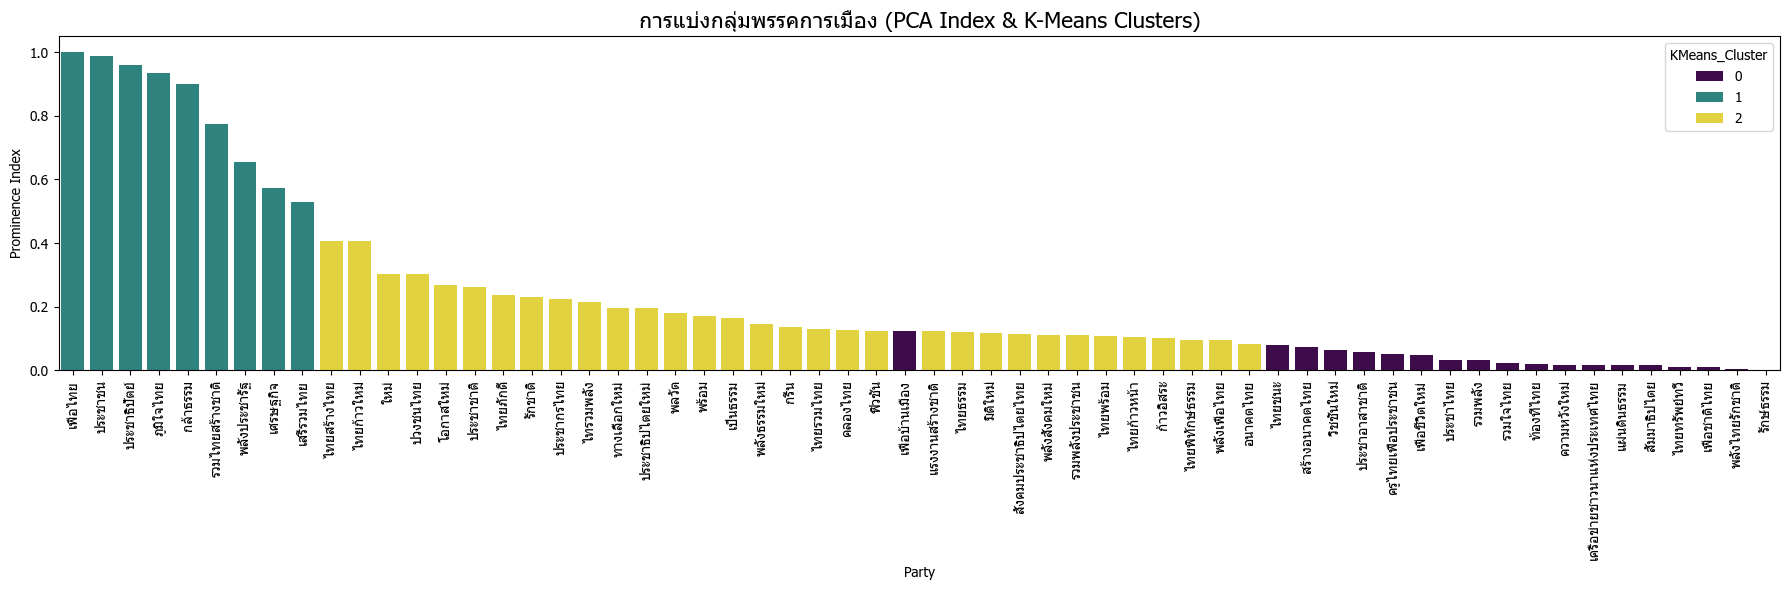

------------------------------
สรุปรายชื่อพรรคในแต่ละกลุ่ม:
------------------------------

Group A (Famous/Major) [Cluster 1] - 9 พรรค:
เพื่อไทย, ประชาชน, ประชาธิปัตย์, ภูมิใจไทย, กล้าธรรม, รวมไทยสร้างชาติ, พลังประชารัฐ, เศรษฐกิจ, เสรีรวมไทย

Group B (Medium) [Cluster 2] - 32 พรรค:
ไทยสร้างไทย, ไทยก้าวใหม่, ใหม่, ปวงชนไทย, โอกาสใหม่, ประชาชาติ, ไทยภักดี, รักชาติ, ประชากรไทย, ไทรวมพลัง, ทางเลือกใหม่, ประชาธิปไตยใหม่, พลวัต, พร้อม, เป็นธรรม, พลังธรรมใหม่, กรีน, ไทยรวมไทย, คลองไทย, ฟิวชัน, แรงงานสร้างชาติ, ไทยธรรม, มิติใหม่, สังคมประชาธิปไตยไทย, พลังสังคมใหม่, รวมพลังประชาชน, ไทยพร้อม, ไทยก้าวหน้า, ก้าวอิสระ, ไทยพิทักษ์ธรรม, พลังเพื่อไทย, อนาคตไทย

Group C (Small/No-Name) [Cluster 0] - 19 พรรค:
เพื่อบ้านเมือง, ไทยชนะ, สร้างอนาคตไทย, วิชชั่นใหม่, ประชาอาสาชาติ, ครูไทยเพื่อประชาชน, เพื่อชีวิตใหม่, ประชาไทย, รวมพลัง, รวมใจไทย, ท้องที่ไทย, ความหวังใหม่, เครือข่ายชาวนาแห่งประเทศไทย, แผ่นดินธรรม, สัมมาธิปไตย, ไทยทรัพย์ทวี, เพื่อชาติไทย, พลังไทยรักชาติ, รักษ์ธรรม


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# --- FIX THAI FONT FOR WINDOWS ---
plt.rcParams['font.family'] = 'Tahoma' 
# If Tahoma doesn't work, try 'Leelawadee UI' or 'Angsana New'
# ---------------------------------

cols = [
    'sent_pm_district_ratio', 'sent_pm_partylist_ratio', 
    'social_media_followers_scaled', 'branch_scaled', 
    'representative_scaled', 'member_scaled', 
    'trends_scaled', 'past_pm'
]

# 1. K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(df[cols])

# 2. PCA
pca = PCA(n_components=1)
df['PCA_Index'] = pca.fit_transform(df[cols])

# Ensure positive direction for "fame"
if df[['PCA_Index', 'past_pm']].corr().iloc[0, 1] < 0:
    df['PCA_Index'] *= -1

# Normalize PCA index 0 to 1
df['PCA_Index'] = (df['PCA_Index'] - df['PCA_Index'].min()) / (df['PCA_Index'].max() - df['PCA_Index'].min())

# Sort for plotting
df_sorted = df.sort_values(by='PCA_Index', ascending=False)

# --- PLOT ---
plt.figure(figsize=(18, 6))
sns.barplot(data=df_sorted, x='Party', y='PCA_Index', hue='KMeans_Cluster', palette='viridis', dodge=False)
plt.title('การแบ่งกลุ่มพรรคการเมือง (PCA Index & K-Means Clusters)', fontsize=16)
plt.xticks(rotation=90)
plt.ylabel('Prominence Index')
plt.tight_layout()
plt.show()

# --- SHOW EVERY PARTY IN EACH GROUP ---
print("-" * 30)
print("สรุปรายชื่อพรรคในแต่ละกลุ่ม:")
print("-" * 30)

# Sort clusters by their average PCA index so they appear in order of "Famous" to "No Name"
cluster_order = df.groupby('KMeans_Cluster')['PCA_Index'].mean().sort_values(ascending=False).index

for i, cluster_id in enumerate(cluster_order):
    group_name = ["Group A (Famous/Major)", "Group B (Medium)", "Group C (Small/No-Name)"][i]
    parties = df[df['KMeans_Cluster'] == cluster_id].sort_values('PCA_Index', ascending=False)['Party'].tolist()
    
    print(f"\n{group_name} [Cluster {cluster_id}] - {len(parties)} พรรค:")
    print(", ".join(parties))


In [10]:
# use green as threshold
green_threshold = df.loc[df['Party'] == 'กรีน', 'PCA_Index'].values[0]

df['small'] = (df['PCA_Index'] <= green_threshold).astype(float)

print(f"Threshold (PCA พรรคกรีน): {green_threshold:.4f}")

df

Threshold (PCA พรรคกรีน): 0.1374


,Party,sent_pm_district_ratio,sent_pm_partylist_ratio,social_media_followers_scaled,branch_scaled,representative_scaled,member_scaled,trends_scaled,past_pm,KMeans_Cluster,PCA_Index,small
0,กรีน,0.0050,0.12,0.652096,0.233333,0.041096,0.493140,0.006485,0.0,2,0.137355,1.0
1,กล้าธรรม,0.8350,1.00,0.836410,0.200000,0.958904,1.000000,0.373541,1.0,1,0.900938,0.0
2,ก้าวอิสระ,0.0150,0.15,0.668957,0.000000,0.000000,0.000000,0.000000,0.0,2,0.100323,1.0
3,ครูไทยเพื่อประชาชน,0.0025,0.22,0.000000,0.200000,0.041096,0.598036,0.000000,0.0,0,0.052685,1.0
4,คลองไทย,0.0050,0.16,0.520813,0.133333,0.000000,0.696621,0.000000,0.0,2,0.125388,1.0
5,ความหวังใหม่,0.0025,0.08,0.000000,0.166667,0.027397,0.499099,0.003891,0.0,0,0.018355,1.0
6,ทางเลือกใหม่,0.1075,0.20,0.596248,0.833333,0.041096,0.704720,0.060960,0.0,2,0.197390,0.0
7,ท้องที่ไทย,0.0050,0.08,0.000000,0.166667,0.027397,0.533464,0.000000,0.0,0,0.020618,1.0
8,ประชากรไทย,0.1050,0.18,0.653730,0.500000,0.273973,0.616066,0.016861,0.0,2,0.223610,0.0
9,ประชาชน,1.0000,0.99,0.966578,0.200000,0.972603,0.893160,0.756161,1.0,1,0.986440,0.0


## Save df to csv

In [11]:
df.to_csv('data/scrape/small_party.csv')

# Detect suspicious score patterns

In [34]:
import os
import glob
import pandas as pd
import numpy as np

small_parties = df[df['small'] == 1.0]['Party'].tolist()

# map typo
typo_mapping = {
    'พิวซัน': 'ฟิวชัน',
    'สรางอนาคตไทย': 'สร้างอนาคตไทย'
}

base_path = 'data/ocr'
csv_files = glob.glob(os.path.join(base_path, '**', 'summary_บัญชีรายชื่อ.csv'), recursive=True)

results = []
error_files = []

# Threshold
threshold_percent = 6.5

for file_path in csv_files:
    # this case does not have partylist file
    if 'ล่วงหน้านอกเขตและนอกราชอาณาจักร' in file_path:
        continue
        
    try:
        temp_df = pd.read_csv(file_path)
        
        if temp_df.empty:
            continue
            
        row = temp_df.iloc[0]
        
        amphoe = row.get('metadata.amphoe', 'N/A')
        tambon = row.get('metadata.tambon', 'N/A')
        unit = row.get('metadata.unit', 'N/A')
        
        if pd.isna(amphoe): amphoe = 'N/A'
        if pd.isna(tambon): tambon = 'N/A'
        if pd.isna(unit): unit = 'N/A'
        
        valid_ballots = row.get('valid_ballots', 0)
        try:
            valid_ballots = float(valid_ballots)
        except:
            valid_ballots = 0
            
        suspect = 0.0
        
        if valid_ballots > 0:
            score_cols = [c for c in temp_df.columns if str(c).startswith('scores.')]
            
            for col in score_cols:
                party_name_in_csv = col.replace('scores.', '')
                
                party_name = typo_mapping.get(party_name_in_csv, party_name_in_csv)
                
                if party_name in small_parties:
                    score = row[col]
                    try:
                        score = float(score)
                    except:
                        score = 0
                        
                    percentage = (score / valid_ballots) * 100
                    
                    if percentage > threshold_percent:
                        suspect = 1.0
                        break
        
        results.append({
            'Amphoe': amphoe,
            'Tambon': tambon,
            'Unit': unit,
            'Suspect': suspect
        })
        
    except Exception as e:
        error_files.append((file_path, str(e)))

final_df = pd.DataFrame(results)

suspicious_count = (final_df['Suspect'] == 1.0).sum()
normal_count = (final_df['Suspect'] == 0.0).sum()

print("=== Processing Summary ===")
print(f"Total units processed : {len(final_df)}")
print(f"Suspicious units      : {suspicious_count}")
print(f"Normal units          : {normal_count}")
print("==========================")

# Display error
if error_files:
    print(f"\n[!] Errors encountered in {len(error_files)} files:")
    for filepath, err in error_files[:10]:
        print(f"  - {filepath}: {err}")
    if len(error_files) > 10:
        print(f"  ... and {len(error_files) - 10} more errors.")
else:
    print("\nNo errors encountered during processing!")

final_df.to_csv('data/suspect.csv')

final_df

=== Processing Summary ===
Total units processed : 279
Suspicious units      : 50
Normal units          : 229

No errors encountered during processing!


,Amphoe,Tambon,Unit,Suspect
0,ล่วงหน้าในเขต,N/A,N/A,0.0
1,อำเภอบ้านไร่,ตำบลคอกควาย,หน่วยเลือกตั้งที่ 1,0.0
2,อำเภอบ้านไร่,ตำบลคอกควาย,หน่วยเลือกตั้งที่ 10,0.0
3,อำเภอบ้านไร่,ตำบลคอกควาย,หน่วยเลือกตั้งที่ 11,0.0
4,อำเภอบ้านไร่,ตำบลคอกควาย,หน่วยเลือกตั้งที่ 12,0.0
...,...,...,...,...
274,อำเภอห้วยคต,ตำบลห้วยคต,หน่วยเลือกตั้งที่ 1,0.0
275,อำเภอห้วยคต,ตำบลห้วยคต,หน่วยเลือกตั้งที่ 4,1.0
276,อำเภอห้วยคต,ตำบลห้วยคต,หน่วยเลือกตั้งที่ 5,0.0
277,อำเภอห้วยคต,ตำบลห้วยคต,หน่วยเลือกตั้งที่ 7,1.0
